# 🔗 Merge NESO Demand with Half‑Hourly Temperature

This notebook merges:

- NESO half‑hourly electricity demand  
- Half‑hourly temperature (from Sutton Bonington)

The result is a unified dataset for forecasting.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/demand_temperature_half_hourly.csv")
df.columns
# Load merged half-hourly dataset




Index(['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD',
       'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION',
       'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION',
       'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING',
       'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW',
       'NEMO_FLOW', 'timestamp', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW',
       'GREENLINK_FLOW', 'SCOTTISH_TRANSFER', 'tmean'],
      dtype='object')

In [13]:
df = pd.read_csv("../data/processed/demand_temperature_half_hourly.csv", parse_dates=["timestamp"])
df = df.rename(columns={"ENGLAND_WALES_DEMAND": "demand"})

# Quick sanity checks
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122736 entries, 0 to 122735
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   SETTLEMENT_DATE            122736 non-null  object        
 1   SETTLEMENT_PERIOD          122736 non-null  int64         
 2   ND                         122736 non-null  int64         
 3   TSD                        122736 non-null  int64         
 4   demand                     122736 non-null  int64         
 5   EMBEDDED_WIND_GENERATION   122736 non-null  int64         
 6   EMBEDDED_WIND_CAPACITY     122736 non-null  int64         
 7   EMBEDDED_SOLAR_GENERATION  122736 non-null  int64         
 8   EMBEDDED_SOLAR_CAPACITY    122736 non-null  int64         
 9   NON_BM_STOR                122736 non-null  int64         
 10  PUMP_STORAGE_PUMPING       122736 non-null  int64         
 11  IFA_FLOW                   122736 non-null  int64   

,SETTLEMENT_PERIOD,ND,TSD,demand,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,...,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,timestamp,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SCOTTISH_TRANSFER,tmean
count,122736.000000,122736.000000,122736.000000,122736.000000,122736.000000,122736.000000,122736.000000,122736.000000,122736.000000,122736.000000,...,122736.000000,122736.000000,122736.000000,122736,105216.000000,105216.000000,105216.000000,105216.000000,35088.000000,87696.000000
mean,24.500228,27723.077011,29399.412340,25360.911925,1830.889641,6394.577312,1424.949094,14420.882292,3.824363,217.819833,...,-115.715511,-43.248485,403.486532,2021-07-02 12:20:09.444662016,424.874392,112.794794,70.551599,-0.010835,1656.619500,8.505367
min,1.000000,13367.000000,16513.000000,0.000000,147.000000,5754.000000,0.000000,12663.000000,0.000000,0.000000,...,-505.000000,-585.000000,-1024.000000,2018-01-01 00:00:00,-1455.000000,-1028.000000,-1465.000000,-159.000000,-2851.000000,6.893596
25%,12.750000,22643.000000,24638.000000,20710.000000,908.000000,6231.000000,0.000000,13052.000000,0.000000,7.000000,...,-404.000000,-291.000000,0.000000,2019-10-02 06:52:30,0.000000,0.000000,0.000000,0.000000,90.750000,7.833352
50%,24.500000,26940.500000,28584.000000,24597.000000,1541.000000,6527.000000,6.000000,13725.000000,0.000000,11.000000,...,-124.000000,0.000000,591.000000,2021-07-02 12:45:00,0.000000,0.000000,0.000000,0.000000,1433.000000,7.833352
75%,36.250000,31916.000000,33224.000000,29189.250000,2526.000000,6545.000000,2299.000000,15505.000000,0.000000,146.000000,...,107.000000,115.000000,926.000000,2023-04-02 18:37:30,1095.000000,48.000000,0.000000,0.000000,3030.250000,7.833352
max,50.000000,49807.000000,50608.000000,46356.000000,5962.000000,6622.000000,11498.000000,18720.000000,684.000000,1963.000000,...,499.000000,504.000000,1033.000000,2024-12-31 23:30:00,1401.000000,1002.000000,1436.000000,27.000000,6704.000000,16.294614
std,13.853851,6496.311478,6187.880584,5929.665153,1154.171060,247.229205,2213.438327,1722.491747,33.382920,411.756034,...,276.375343,316.982405,563.394517,NaN,653.339317,487.699380,348.670253,0.592911,1862.106625,2.022477


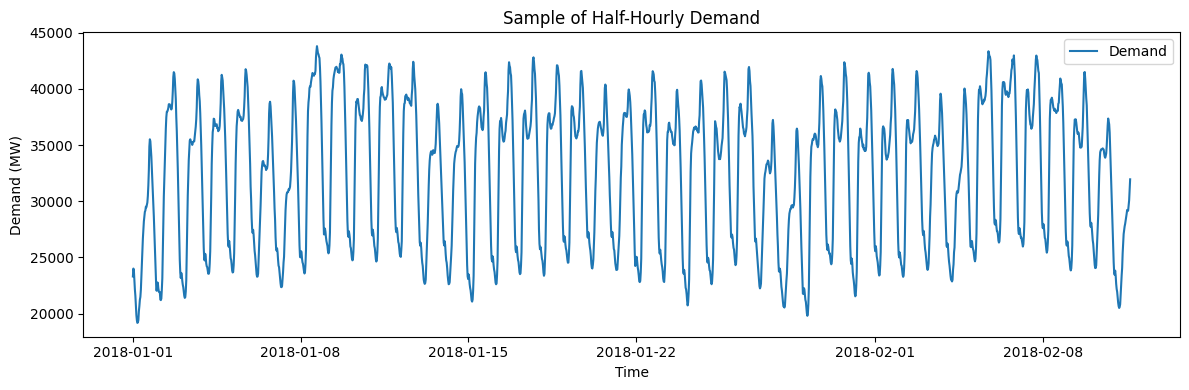

In [14]:
# Plot demand over time (sample)
sample = df.iloc[:2000]  # avoid plotting millions of points

plt.figure(figsize=(12, 4))
plt.plot(sample["timestamp"], sample["demand"], label="Demand")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.title("Sample of Half-Hourly Demand")
plt.legend()
plt.tight_layout()
plt.show()




In [16]:
import pandas as pd
df = pd.read_csv("../data/processed/temperature_half_hourly.csv")
print(df.columns)


Index(['date', 'tmean'], dtype='object')


In [18]:
import pandas as pd
df = pd.read_csv("../data/processed/demand_temperature_half_hourly.csv")
print(df.columns)


Index(['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD', 'demand',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY',
       'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR',
       'PUMP_STORAGE_PUMPING', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
       'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'timestamp', 'NSL_FLOW',
       'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW', 'SCOTTISH_TRANSFER',
       'tmean'],
      dtype='object')
